# Task 1 — Preprocess and Explore the Data

Fetch historical data for **TSLA**, **BND**, and **SPY** (2015-01-01 to 2026-06-30) from Yahoo Finance, clean it, and explore trends, volatility, outliers, and stationarity.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import warnings; warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 110

from src import data_loader, eda, arima_model, lstm_model, portfolio, backtest


## 1.1 Fetch & clean data

In [2]:
raw = data_loader.fetch_asset_data(cache_dir='../data/raw')
cleaned = data_loader.clean_asset_data(raw)
quality = data_loader.data_quality_report(raw, cleaned)
quality

2026-07-04 07:45:31,225 [INFO] Loading cached data for TSLA from ../data/raw/TSLA.csv


2026-07-04 07:45:31,248 [INFO] Loading cached data for BND from ../data/raw/BND.csv


2026-07-04 07:45:31,265 [INFO] Loading cached data for SPY from ../data/raw/SPY.csv


2026-07-04 07:45:31,313 [INFO] TSLA: reindexed to 2997 business days, filled 109 missing trading days


2026-07-04 07:45:31,319 [INFO] BND: reindexed to 2997 business days, filled 109 missing trading days


2026-07-04 07:45:31,327 [INFO] SPY: reindexed to 2997 business days, filled 109 missing trading days


,ticker,raw_rows,raw_missing_values,cleaned_rows,cleaned_missing_values,date_range
0,TSLA,2888,0,2997,0,2015-01-02 to 2026-06-29
1,BND,2888,0,2997,0,2015-01-02 to 2026-06-29
2,SPY,2888,0,2997,0,2015-01-02 to 2026-06-29


## 1.2 Combine adjusted close prices and compute daily returns

In [3]:
prices = data_loader.combine_asset_data(cleaned, field='Adj Close')
returns = data_loader.compute_daily_returns(prices)
prices.tail()

,TSLA,BND,SPY
Date,,,
2026-06-23,381.609985,72.976631,733.580017
2026-06-24,375.529999,73.305534,733.239990
2026-06-25,375.119995,73.355370,734.299988
2026-06-26,379.709991,73.425133,728.989990
2026-06-29,411.839996,73.465004,741.000000


## 1.3 Summary statistics & basic risk metrics (VaR, Sharpe)

In [4]:
stats = eda.summary_statistics(prices, returns)
stats.round(3)

,start_price,end_price,total_return_pct,annualized_return_pct,annualized_volatility_pct,sharpe_ratio,var_95_daily_pct,skew,kurtosis
asset,,,,,,,,,
TSLA,14.621,411.840,2716.834,54.857,56.130,0.745,5.110,0.304,4.749
BND,59.405,73.465,23.667,1.942,5.216,-0.011,0.472,-0.932,37.976
SPY,169.688,741.000,336.684,14.916,17.331,0.688,1.635,-0.308,14.661


## 1.4 Visualize normalized closing prices

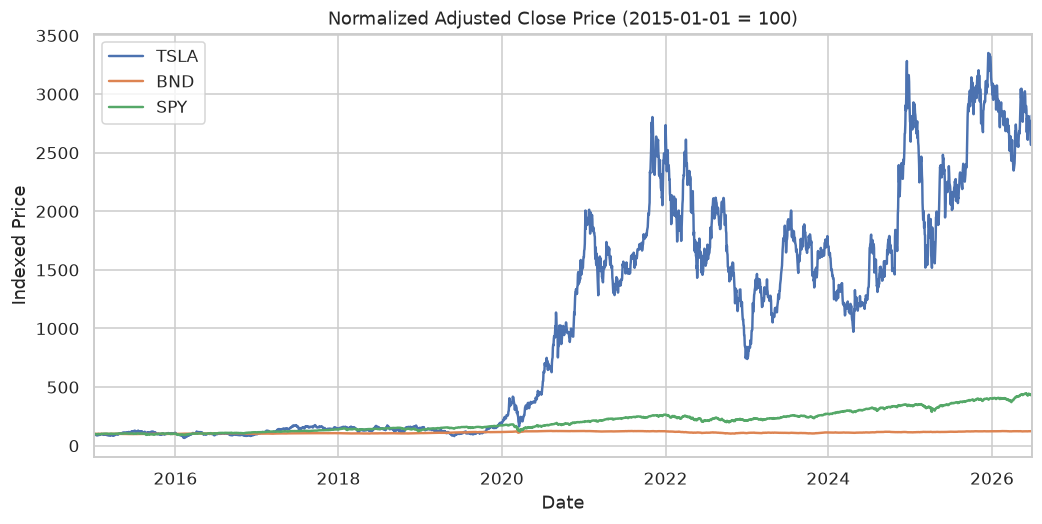

In [5]:
normalized = prices / prices.iloc[0] * 100
fig, ax = plt.subplots(figsize=(11, 5))
normalized.plot(ax=ax, linewidth=1.6)
ax.set_title('Normalized Adjusted Close Price (2015-01-01 = 100)')
ax.set_ylabel('Indexed Price'); plt.show()

## 1.5 Daily percentage change (volatility) by asset

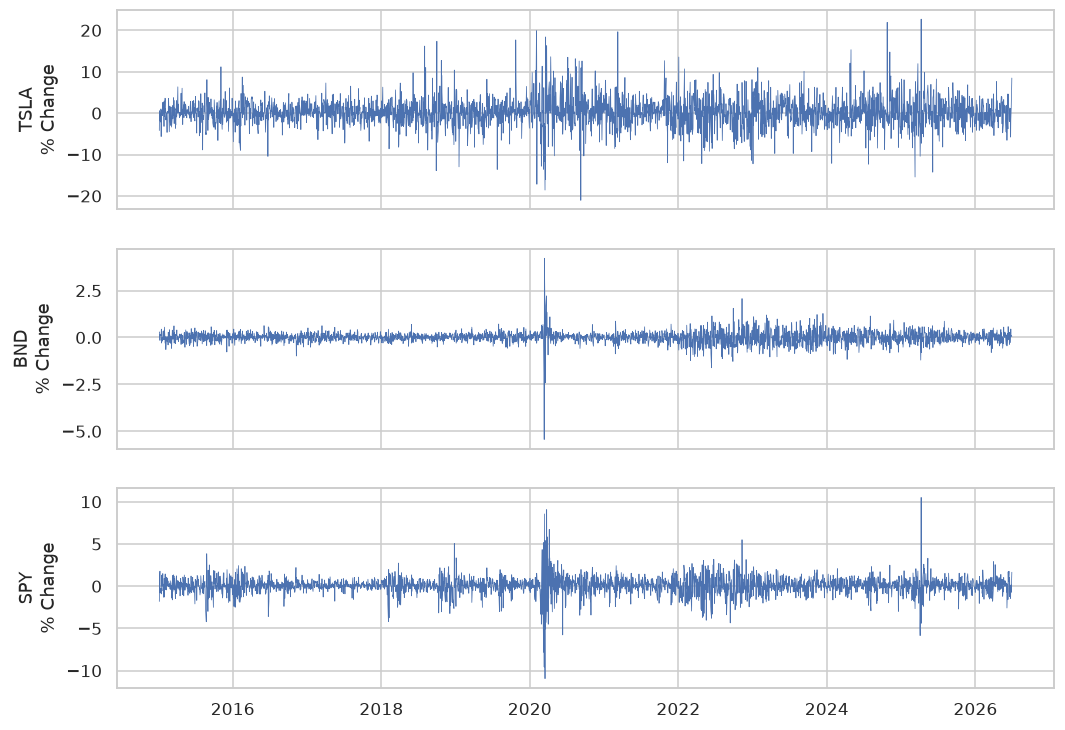

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
for i, col in enumerate(returns.columns):
    axes[i].plot(returns.index, returns[col]*100, linewidth=0.5)
    axes[i].set_ylabel(f'{col}\n% Change')
plt.show()

## 1.6 Rolling mean/volatility and outlier detection for TSLA

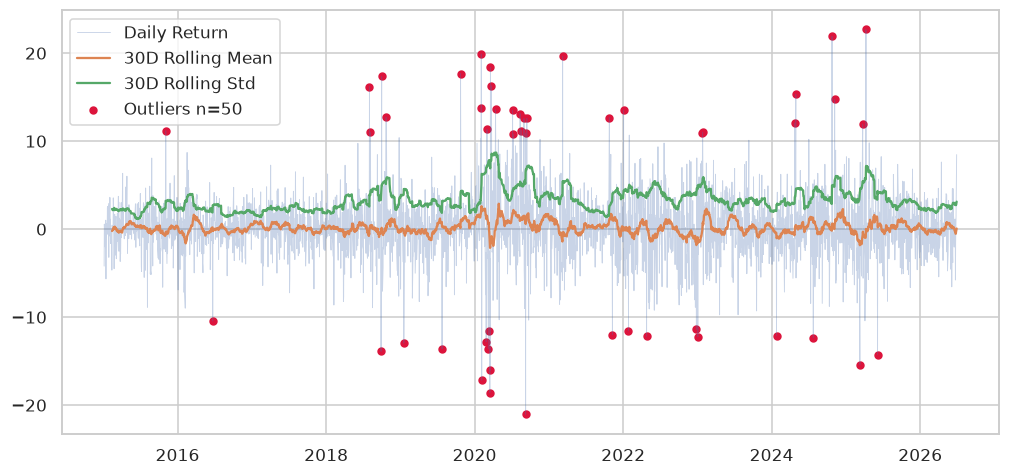

In [7]:
roll_mean, roll_std = eda.rolling_stats(returns['TSLA'], window=30)
outliers = eda.detect_outliers(returns['TSLA'], n_std=3.0)
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(returns.index, returns['TSLA']*100, alpha=0.3, linewidth=0.6, label='Daily Return')
ax.plot(roll_mean.index, roll_mean*100, label='30D Rolling Mean')
ax.plot(roll_std.index, roll_std*100, label='30D Rolling Std')
ax.scatter(outliers.index, outliers*100, color='crimson', s=20, label=f'Outliers n={len(outliers)}')
ax.legend(); plt.show()

## 1.7 Stationarity testing (Augmented Dickey-Fuller)

Test both raw prices and daily returns for each asset. We expect **prices to be non-stationary** (unit root, trending) and **returns to be stationary** — this justifies modeling returns/differenced series rather than raw prices.

In [8]:
results = []
for col in prices.columns:
    results.append(eda.adf_test(prices[col], label=f'{col}_price'))
    results.append(eda.adf_test(returns[col], label=f'{col}_return'))
adf_df = pd.DataFrame([{'series': r['label'], 'adf_stat': r['adf_statistic'], 'p_value': r['p_value'], 'verdict': r['verdict']} for r in results])
adf_df

,series,adf_stat,p_value,verdict
0,TSLA_price,-1.038692,7.388921e-01,non-stationary
1,TSLA_return,-55.149764,0.000000e+00,stationary
2,BND_price,-1.116581,7.084145e-01,non-stationary
3,BND_return,-21.277144,0.000000e+00,stationary
4,SPY_price,1.433347,9.972605e-01,non-stationary
5,SPY_return,-15.700587,1.397707e-28,stationary


### Key Insight

All three price series fail to reject the unit-root null hypothesis (p > 0.05), confirming they are **non-stationary random walks with drift** — typical of financial asset prices. All three return series strongly reject the null (p < 0.001) and are **stationary**, which is why forecasting models in Task 2 are built on (differenced) price/return series rather than raw prices directly.